# Exploration 2: feature-level analysis of one continuous omic

Deep dive into one omic (`OMIC`), in-sample (IS) vs out-of-sample (OOD). Reads the metric files; section 7 also
loads the aligned data and sample cube (read-only, via `om.load_prepared`) to draw calibration diagrams.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

import omics_config as cfg
import omics_metrics as om
import omics_plots as op

OMIC = "crisprcas9"       # metabolomics | drugresponse | methylation | proteomics | transcriptomics | crisprcas9
METHOD = "latent"         # "latent" | "mcd"
HIGHLIGHT = None          # feature circled in the scatter plots (None: none)
FEATURE = None            # feature for section 8 (None: the worst-calibrated in-sample feature)
PREPARED_SETTING = "IS"   # data used for the calibration diagrams in section 7
RUN_DIAGRAMS = True       # sections 7-9 load the full data (large omics: several GB)

m = op.load_metrics(METHOD, omics=[OMIC])
info = op.load_raw_feature_info(omics=[OMIC])
tissue = op.load_tissue()
is_, ood = m[OMIC]["IS"], m[OMIC]["OOD"]

Skipped crisprcas9 latent OOD: not evaluated (cfg.UNAVAILABLE)


## 1. Ranges and rankings

In [2]:
display(op.metric_ranges(m, OMIC))
display(is_["sharpness"].mean().sort_values().head(10).rename("lowest mean PIW (IS)"))
display(is_["calibration"].sort_values(ascending=False).head(10).rename("highest ENCE (IS)"))
display(is_["error"].sort_values().head(1).rename("lowest RMSE (IS)"))

,Min,Max
sharpness (IS),0.027407,0.083868
calibration (IS),15.981336,101.882146
scoring (IS),0.315334,0.698106
error (IS),0.467720,0.881988


CYB5A       0.027407
TUT1        0.028262
PARVA       0.028951
ERG         0.029681
ANKRD36     0.029947
GPR160      0.030269
KASH5       0.030342
SIGLEC14    0.030535
GYPB        0.030609
CLEC4C      0.030805
Name: lowest mean PIW (IS), dtype: float64

feature
GYPB        101.882146
TUT1         98.743661
MYL4         96.266493
RFX6         94.883772
ANKRD36      94.827204
SIGLEC14     92.714789
DPPA3        92.522156
OR52H1       91.271905
CSNK2A3      90.762746
SORBS3       90.623413
Name: highest ENCE (IS), dtype: float64

POU2AF1    0.46772
Name: lowest RMSE (IS), dtype: float64

In [3]:
if ood is not None:
    ood_ence = ood["calibration"]
    ence_outliers = op.outliers(ood_ence, method="iqr")
    print(f"OOD ENCE: mean {ood_ence.mean():.4f}; {len(ence_outliers)} IQR outliers out of {ood_ence.notna().sum()} features")
    display(ence_outliers)

    both = pd.concat([is_["calibration"], ood_ence], axis=1, keys=["IS", "OOD"]).dropna()
    better_in_ood = both.index[both["IS"] < both["OOD"]].tolist()
    print(f"{len(better_in_ood)} features have a lower ENCE in-sample than out-of-sample:")
    print(better_in_ood)

## 2. Mean sharpness per observation, by tissue

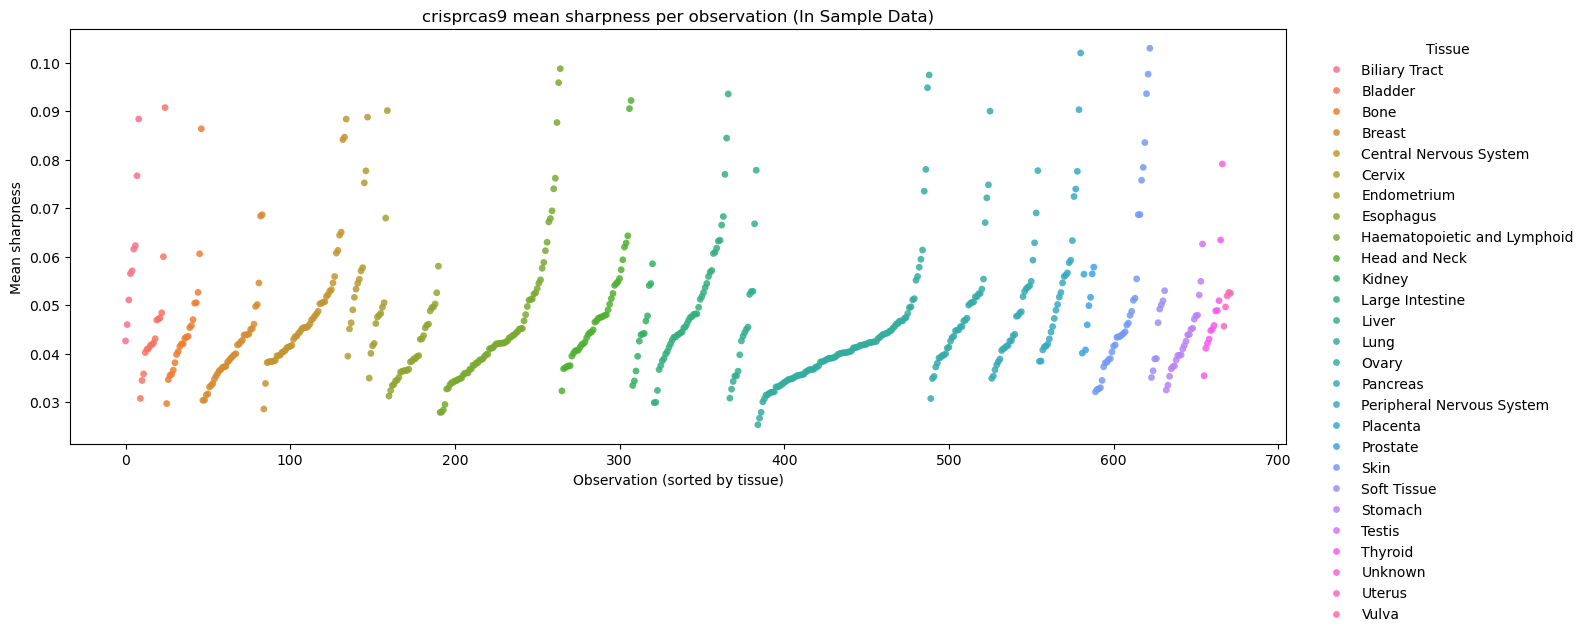

In [4]:
op.plot_obs_sharpness_by_tissue(m, OMIC, tissue, "IS")

## 3. PIW histograms (feature-wise and observation-wise means)

In Sample Data


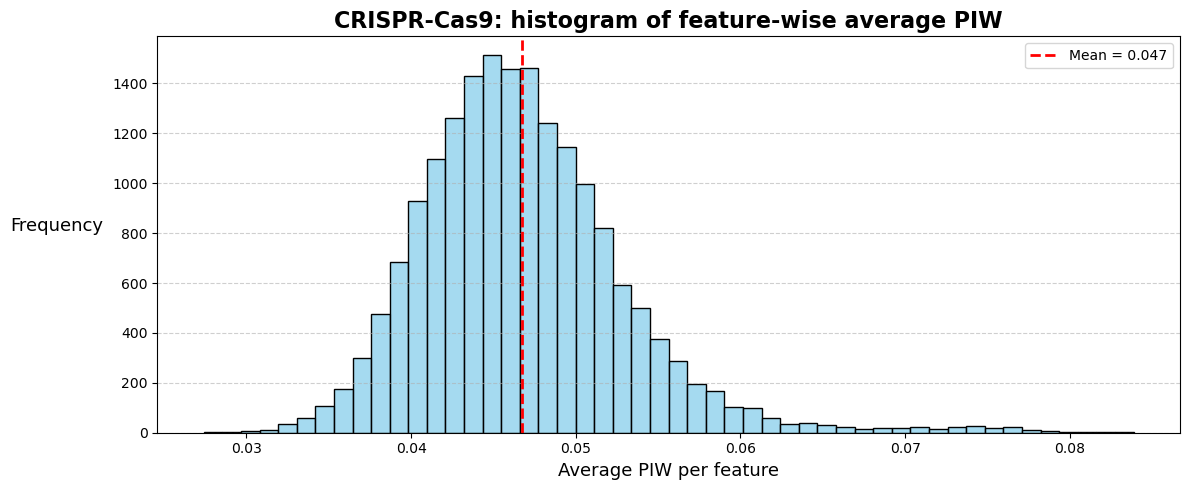

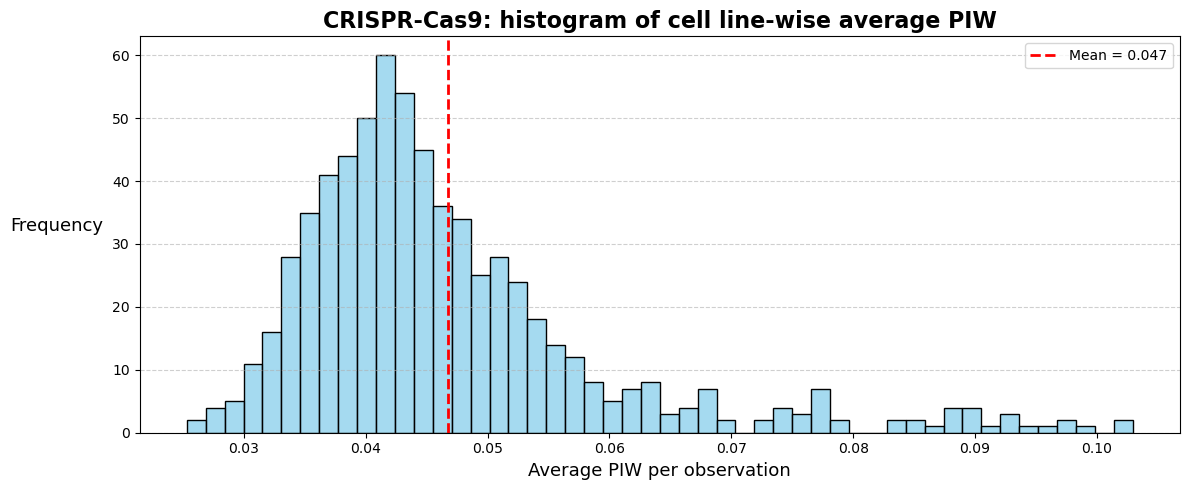

In [5]:
for setting in m[OMIC]:
    print(op.SETTING_LABELS[setting])
    op.plot_mean_histograms(m[OMIC][setting]["sharpness"], OMIC)

## 4. Feature scatter plots
Each point is a feature. The trend line and 95% CI are fitted on all features; `sample` only thins the plotted
points. IS and OOD figures share axis limits and colour scale.

**PIW vs ENCE, coloured by CRPS.**

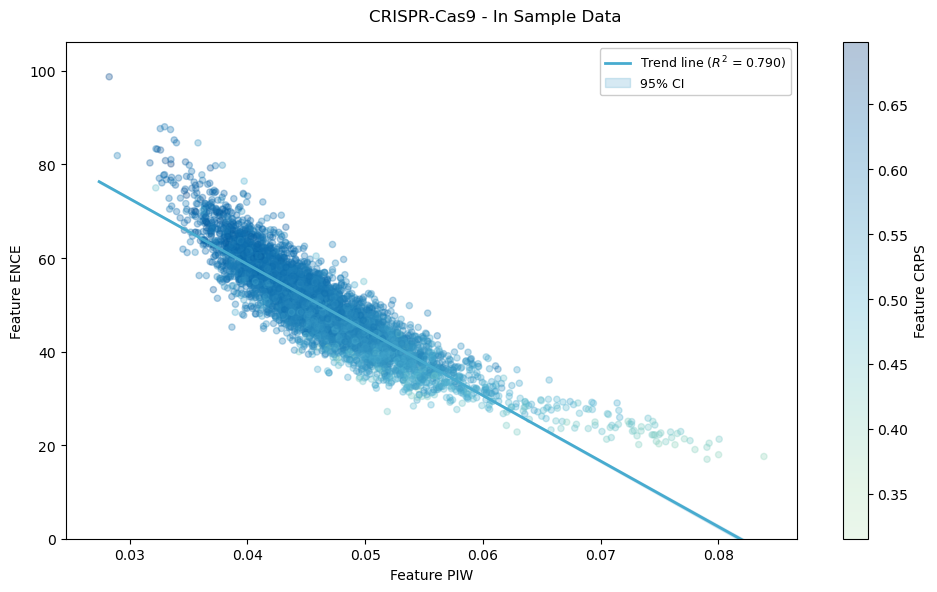

In [6]:
op.compare_is_ood(m, OMIC, sample=0.3, alpha=0.3, highlight=HIGHLIGHT)

With marginal histograms, and with a zoomed inset of the central 99% of features.

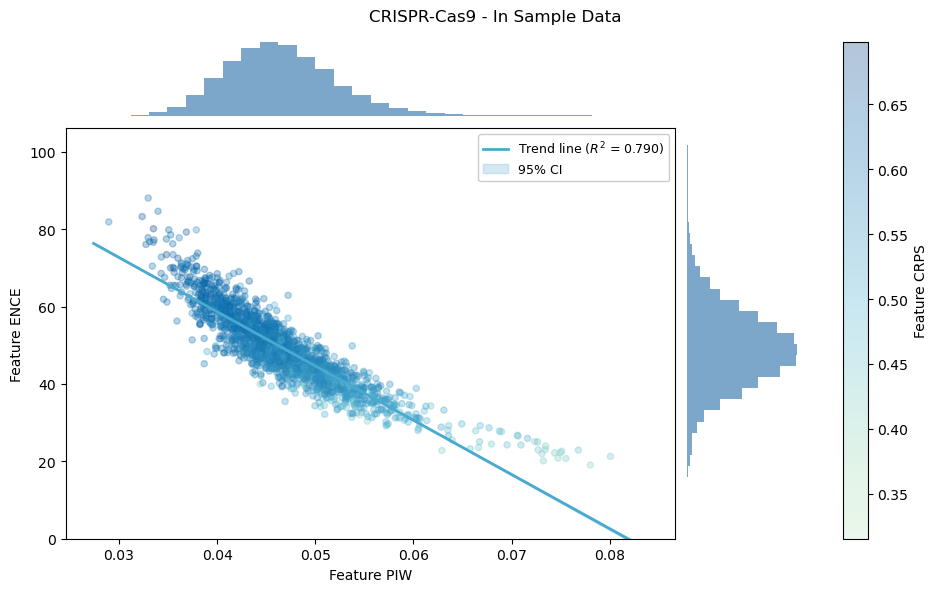

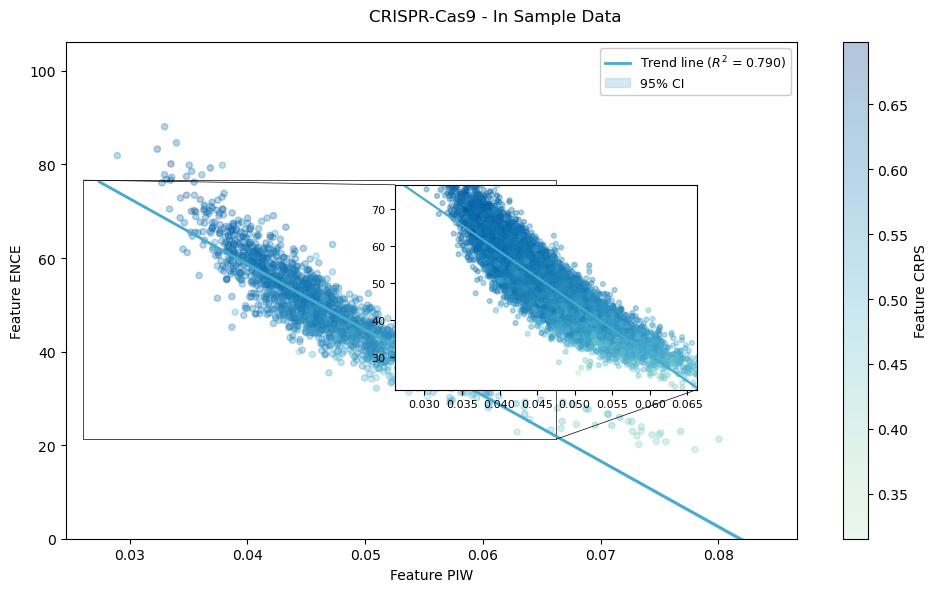

In [7]:
op.compare_is_ood(m, OMIC, sample=0.1, alpha=0.3, marginals=True, highlight=HIGHLIGHT)
op.compare_is_ood(m, OMIC, sample=0.1, alpha=0.3, inset_zoom=True, highlight=HIGHLIGHT)

Other combinations (in-sample).

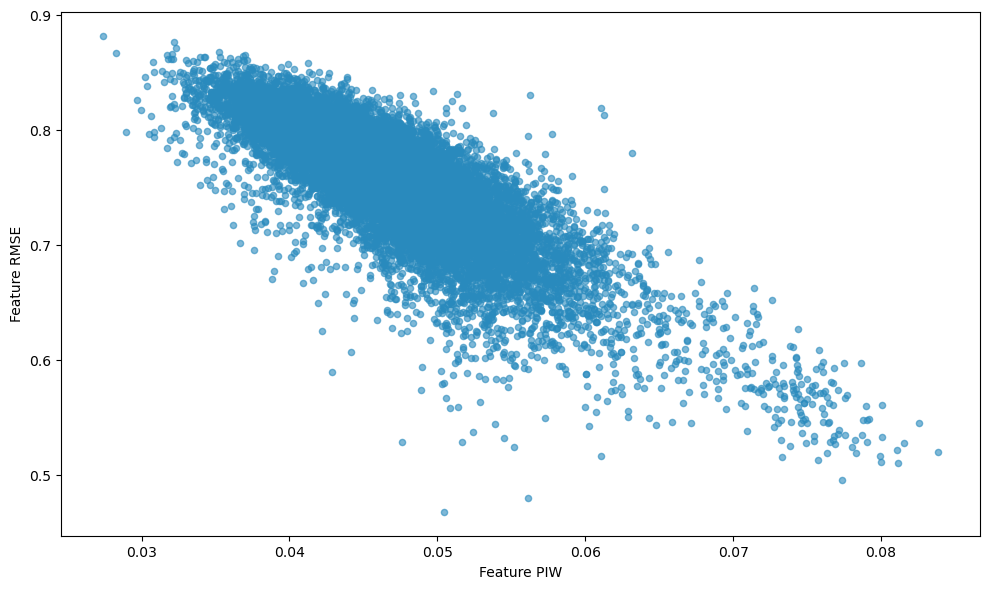

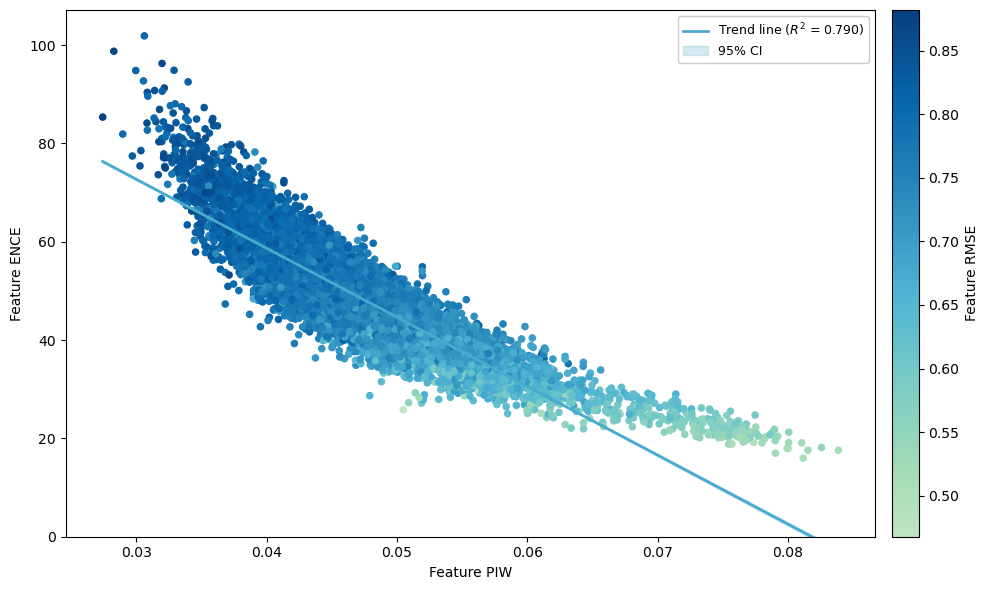

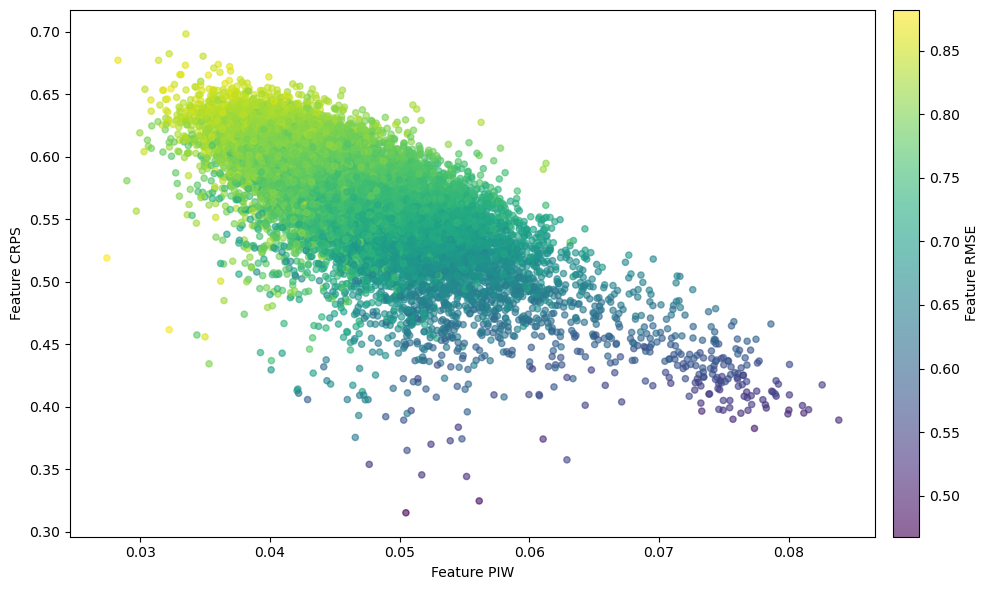

In [8]:
op.feature_scatter(m, OMIC, "IS", x="sharpness", y="error", c=None, trend=False, alpha=0.6)
op.feature_scatter(m, OMIC, "IS", x="sharpness", y="calibration", c="error")
op.feature_scatter(m, OMIC, "IS", x="sharpness", y="scoring", c="error", trend=False, cmap=plt.cm.viridis, alpha=0.6)

**RMSE vs ENCE, coloured by the Pearson correlation of the feature's reconstruction.**

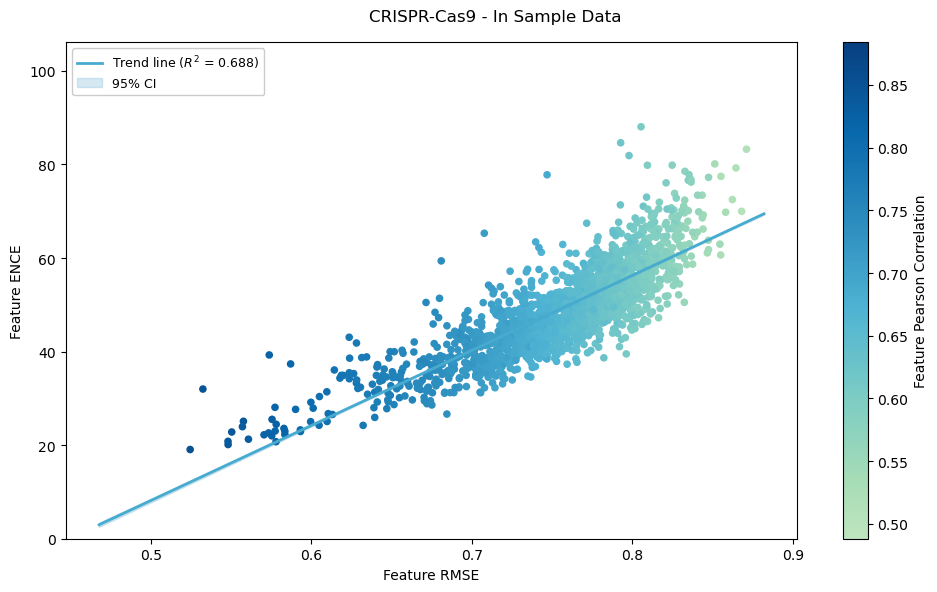

In [9]:
op.compare_is_ood(m, OMIC, x="error", y="calibration", c="pearson", sample=0.1, highlight=HIGHLIGHT, legend_loc="upper left")

## 5. Correlations between feature-level metrics

In [10]:
df = op.feature_table(m, OMIC, "IS", PIW="sharpness", ENCE="calibration")
r, p = pearsonr(df["PIW"], df["ENCE"])
rho, p_rho = spearmanr(df["PIW"], df["ENCE"])
print(f"PIW vs ENCE (IS): Pearson r = {r:.4f} (p = {p:.3e}), Spearman rho = {rho:.4f} (p = {p_rho:.3e})")

PIW vs ENCE (IS): Pearson r = -0.8891 (p = 0.000e+00), Spearman rho = -0.8990 (p = 0.000e+00)


In Sample Data


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Feature\nCorrelation,Original \n Feature's \n Variance
Feature \nPIW,1.000,-0.889,-0.721,-0.824,0.798,0.271
ENCE,-0.889,1.000,0.749,0.829,-0.823,-0.245
CRPS,-0.721,0.749,1.000,0.920,-0.911,-0.222
Feature\nRMSE,-0.824,0.829,0.920,1.000,-0.990,-0.274
Feature\nCorrelation,0.798,-0.823,-0.911,-0.990,1.000,0.260
Original \n Feature's \n Variance,0.271,-0.245,-0.222,-0.274,0.260,1.000


,Feature \nPIW,ENCE,CRPS,Feature\nRMSE,Feature\nCorrelation,Original \n Feature's \n Variance
Feature \nPIW,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.554692e-299
ENCE,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.168279e-242
CRPS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.163617e-199
Feature\nRMSE,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.517452e-306
Feature\nCorrelation,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.987601e-276
Original \n Feature's \n Variance,3.554692e-299,1.168279e-242,1.163617e-199,1.517452e-306,8.987601e-276,0.000000e+00


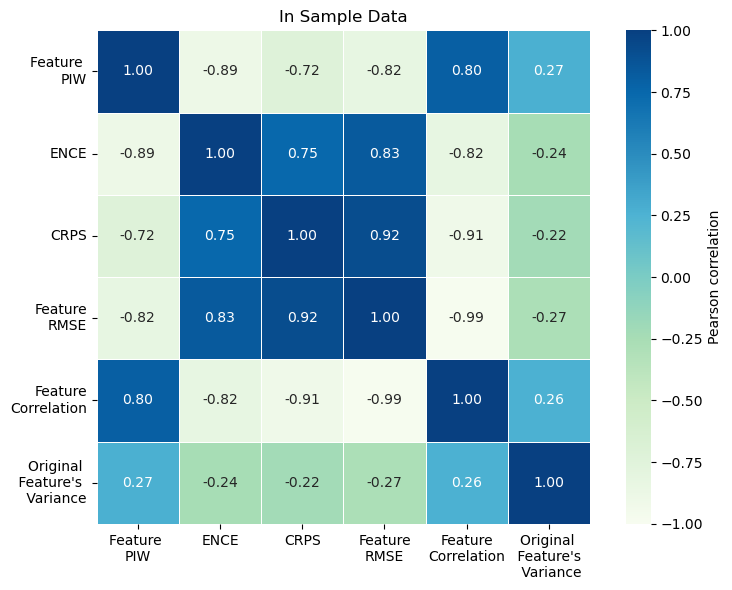

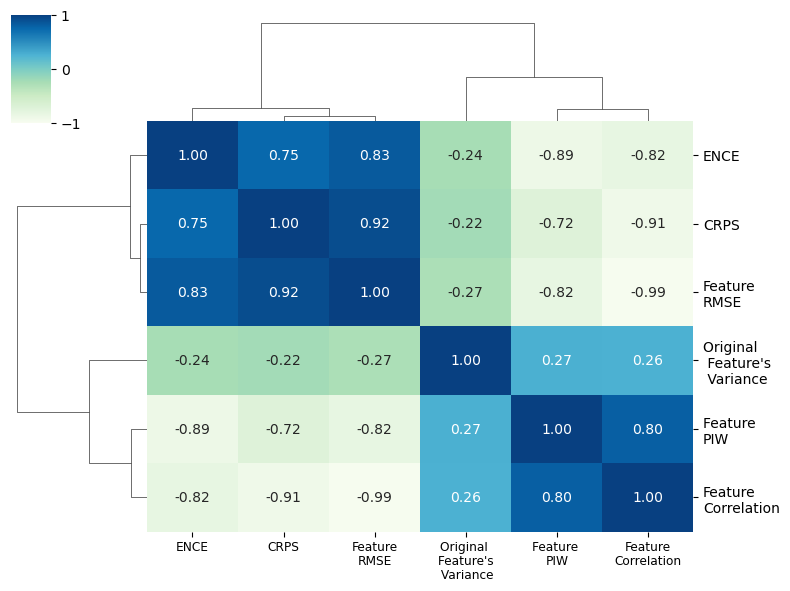

In [11]:
corr = {}
for setting in m[OMIC]:
    table = op.omic_metric_table(m, OMIC, setting, info)
    corr[setting], pvals = op.corr_matrix(table)
    print(op.SETTING_LABELS[setting])
    display(corr[setting].round(3), pvals)
    op.plot_corr_heatmap(corr[setting], title=op.SETTING_LABELS[setting])
    plt.tight_layout()
    plt.show()
op.plot_clustermap(corr.get("OOD", corr["IS"]))

## 6. Missing values in the ground truth
Only for omics with missing values (proteomics, metabolomics, drug response).

In [12]:
MISSING_THRESHOLD = 80   # split features by % missing

if OMIC in cfg.OMICS_WITH_MISSING:
    missing = info[1][OMIC]
    display(missing.describe())
    plt.hist(missing, bins=20)
    plt.xlabel("% missing values")
    plt.ylabel("Features")
    plt.show()
    print(f"{(missing < MISSING_THRESHOLD).sum()} features with < {MISSING_THRESHOLD}% missing, "
          f"{(missing > MISSING_THRESHOLD).sum()} with > {MISSING_THRESHOLD}%")

In [13]:
if OMIC in cfg.OMICS_WITH_MISSING:
    for setting in m[OMIC]:
        df = op.feature_table(m, OMIC, setting, info, x="error", y="calibration", c="missing")
        parts = {f"< {MISSING_THRESHOLD}% missing": df[df["c"] < MISSING_THRESHOLD],
                 f"> {MISSING_THRESHOLD}% missing": df[df["c"] > MISSING_THRESHOLD]}
        for name, part in parts.items():
            if len(part) < 3:
                print(f"{op.SETTING_LABELS[setting]}: {len(part)} features with {name}, not plotted")
                continue
            fig, ax = plt.subplots(figsize=(6, 5))
            op.scatter_trend(ax, part, "x", "y", "c", norm=mpl.colors.Normalize(0, 100), marginals=True, contour=True,
                             xlabel="Feature RMSE", ylabel="Feature ENCE", colorbar="Percentage of missing values")
            ax.set_title(f"{op.SETTING_LABELS[setting]}: {name}")
            plt.show()
    op.compare_is_ood(m, OMIC, x="error", y="calibration", c="missing", info=info, marginals=True, figsize=(6, 5))

## 7. Calibration diagrams
Need the aligned data and samples (`PREPARED_SETTING`). The ENCE shown is the saved one.

* **ENCE reliability**: per bin of predicted std, RMSE against RMV (perfectly calibrated: on the diagonal).
* **Coverage**: fraction of ground-truth values inside the central prediction interval, against its nominal level.

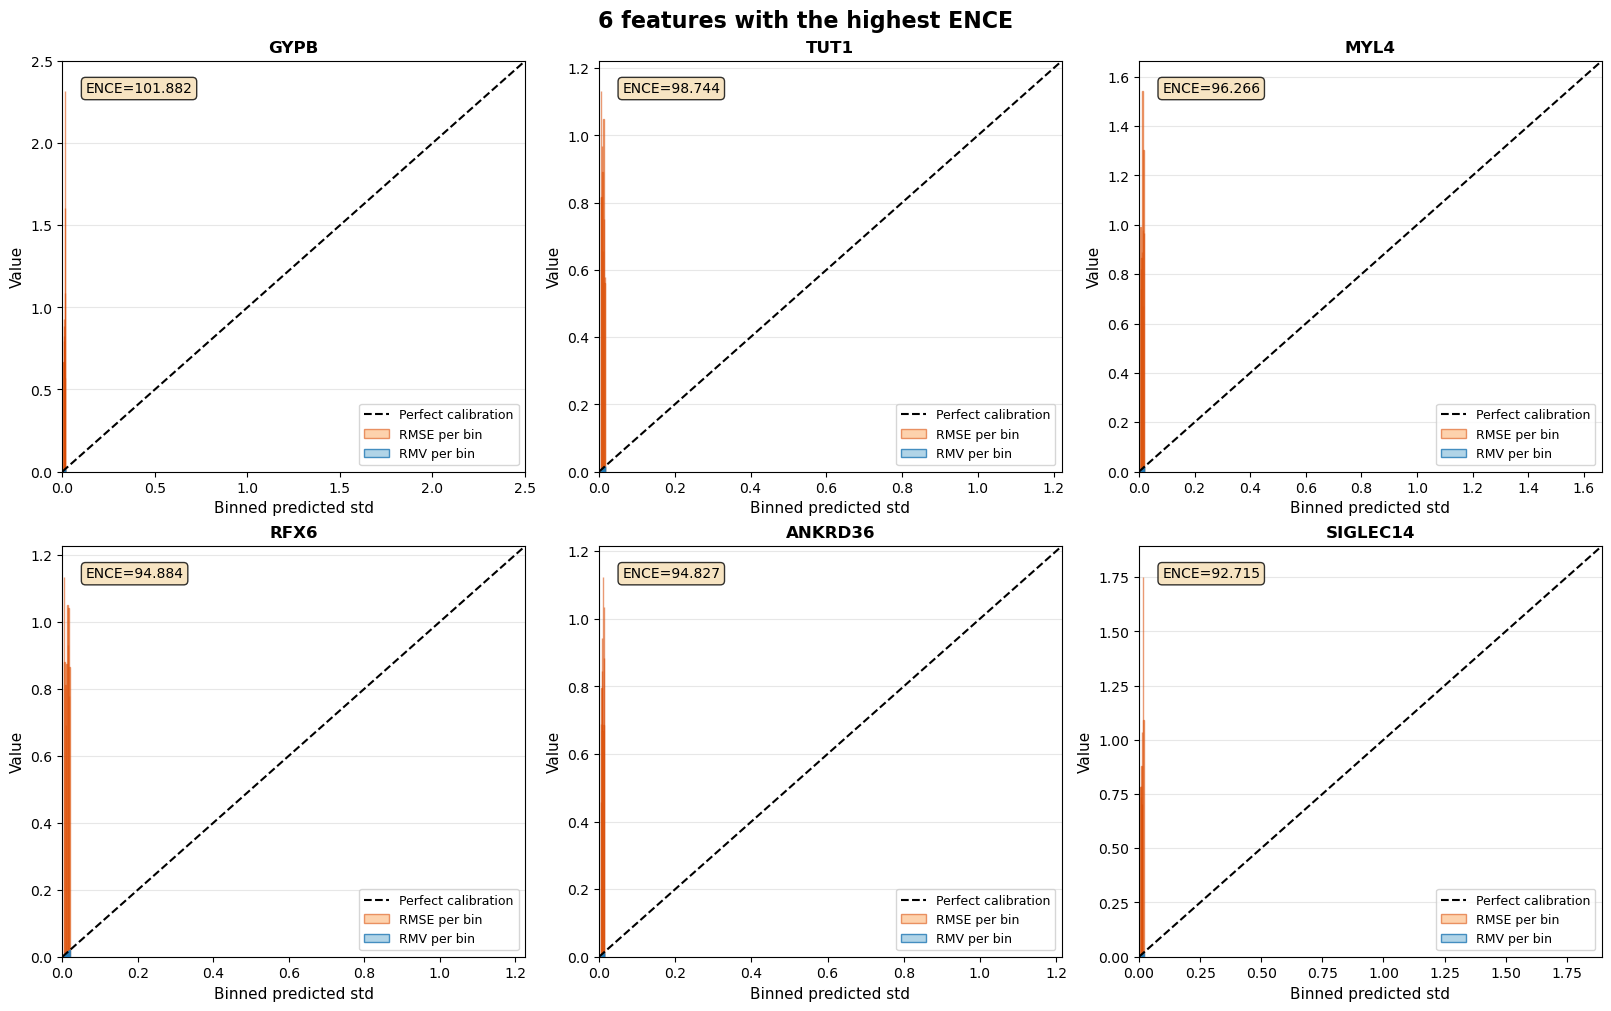

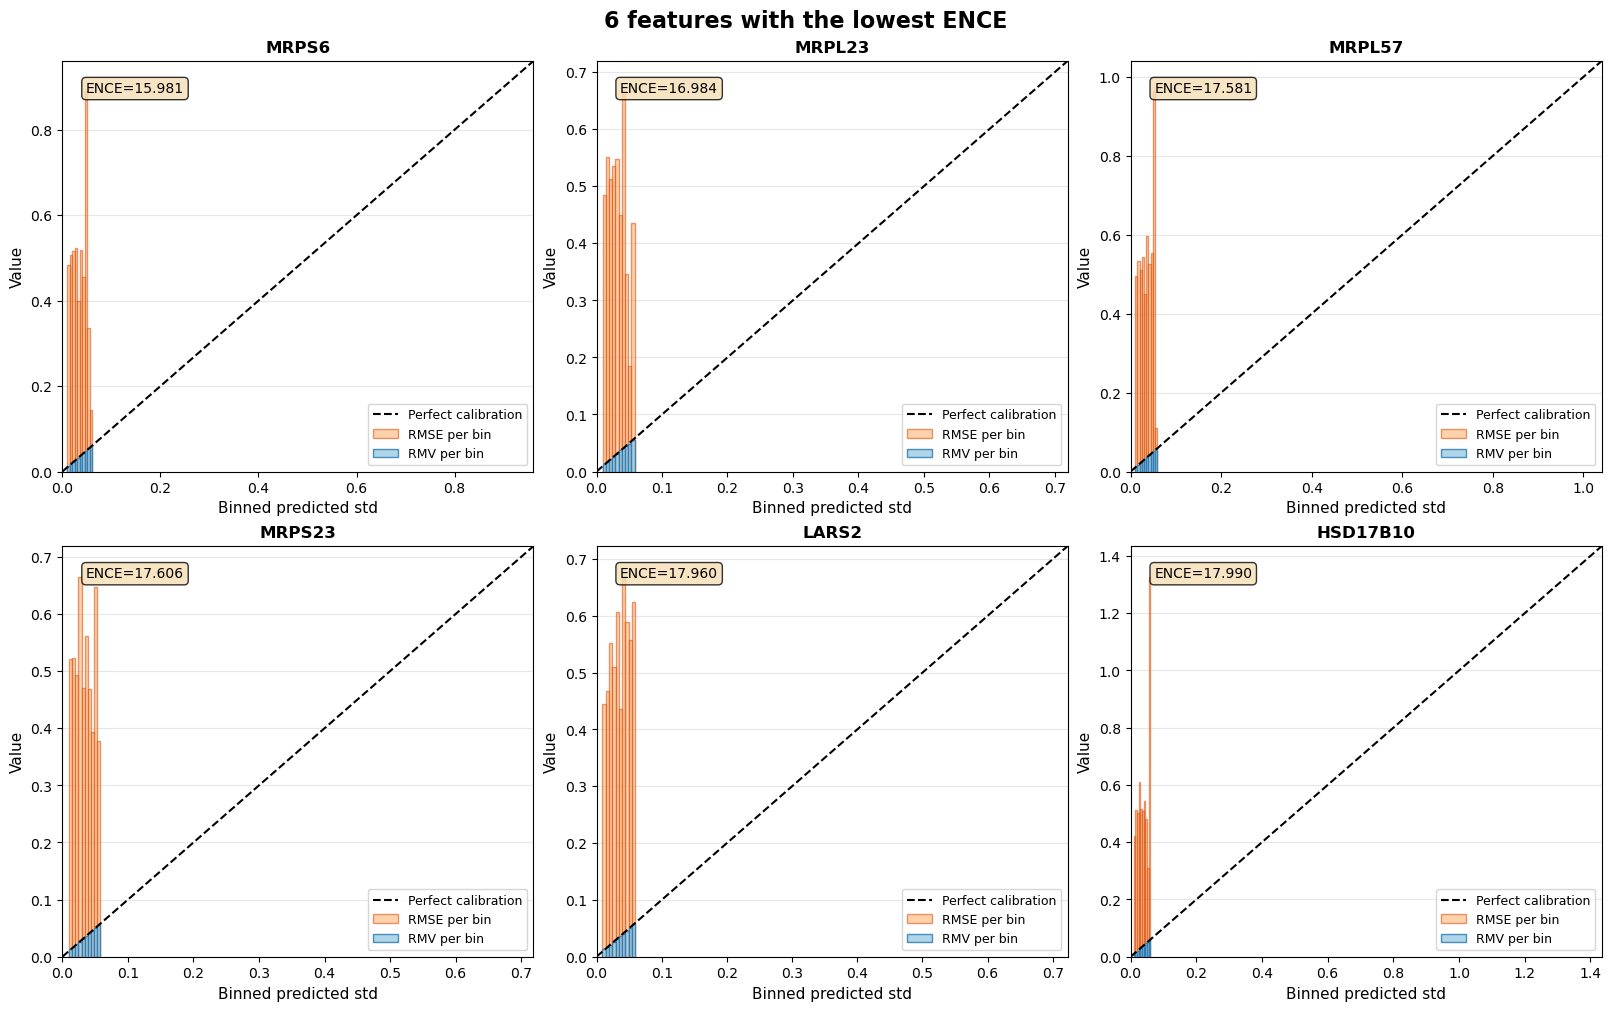

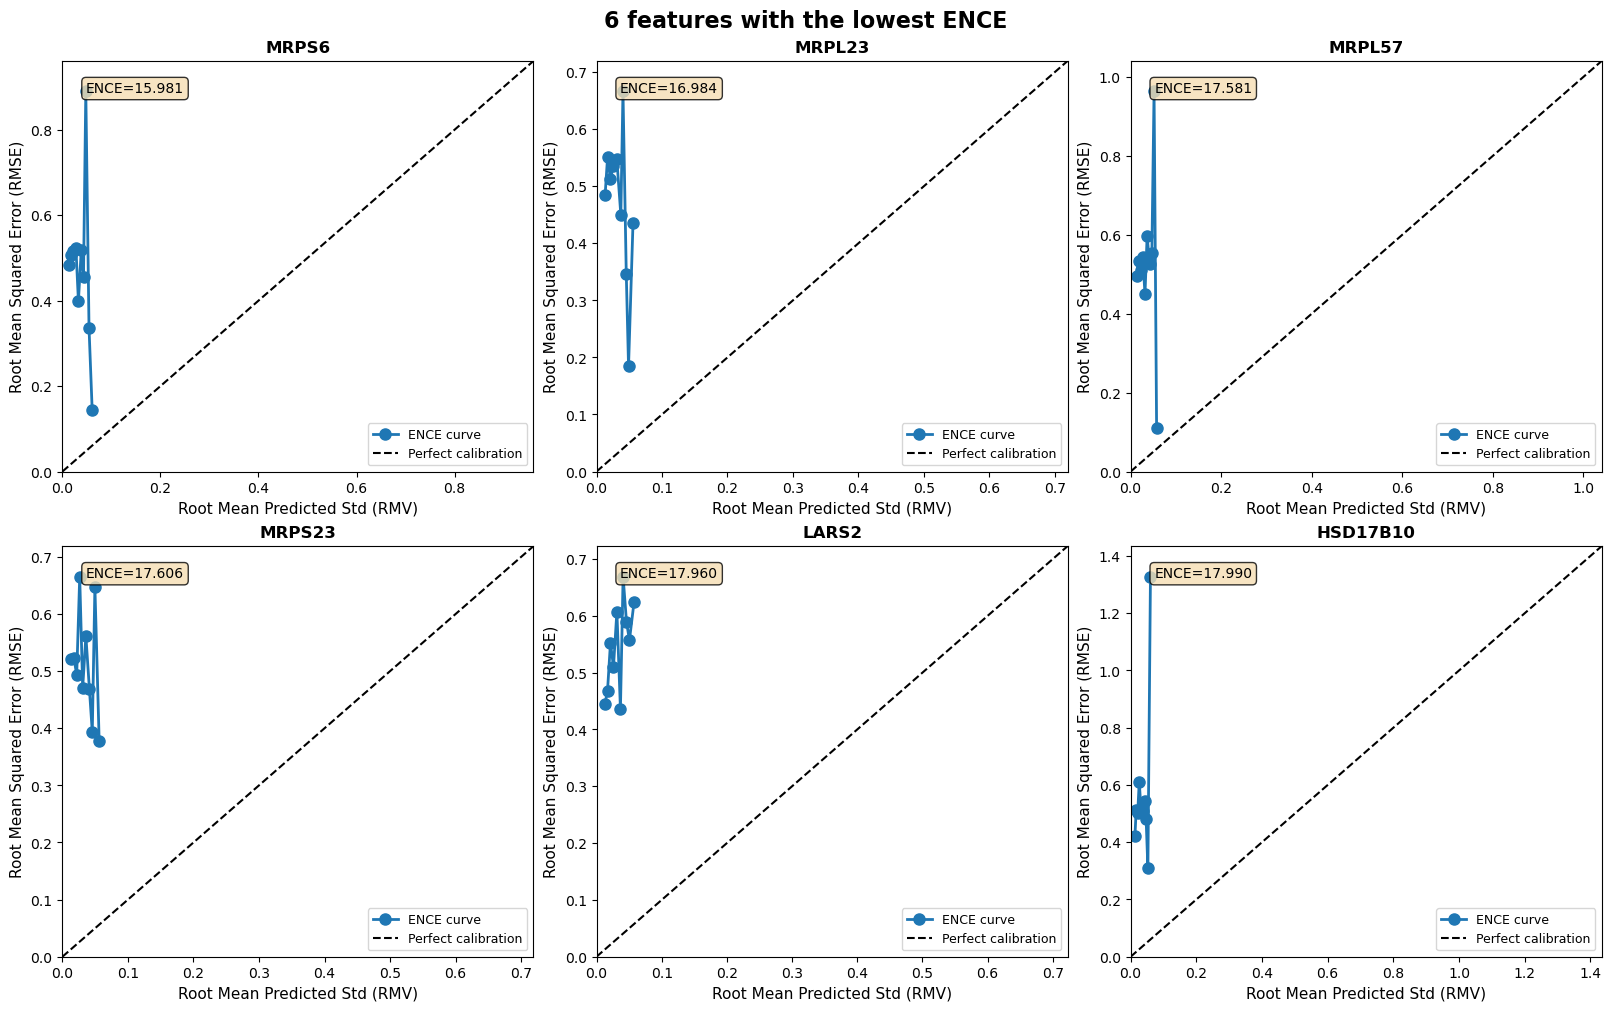

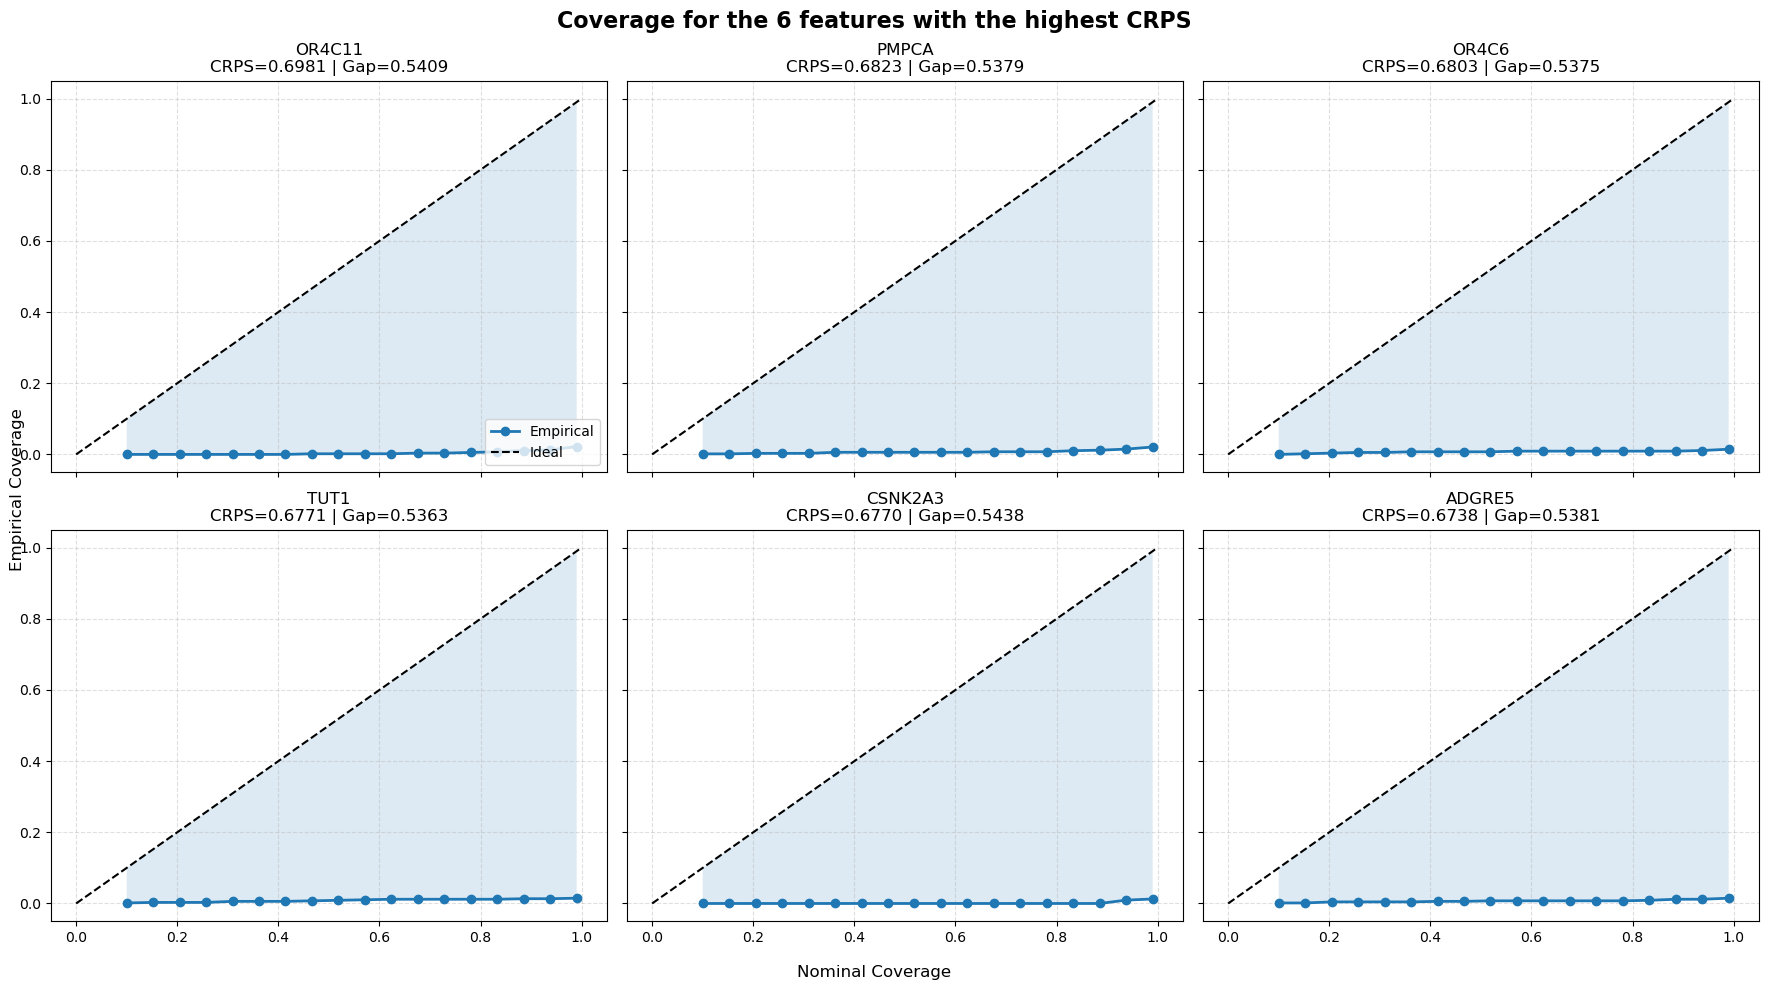

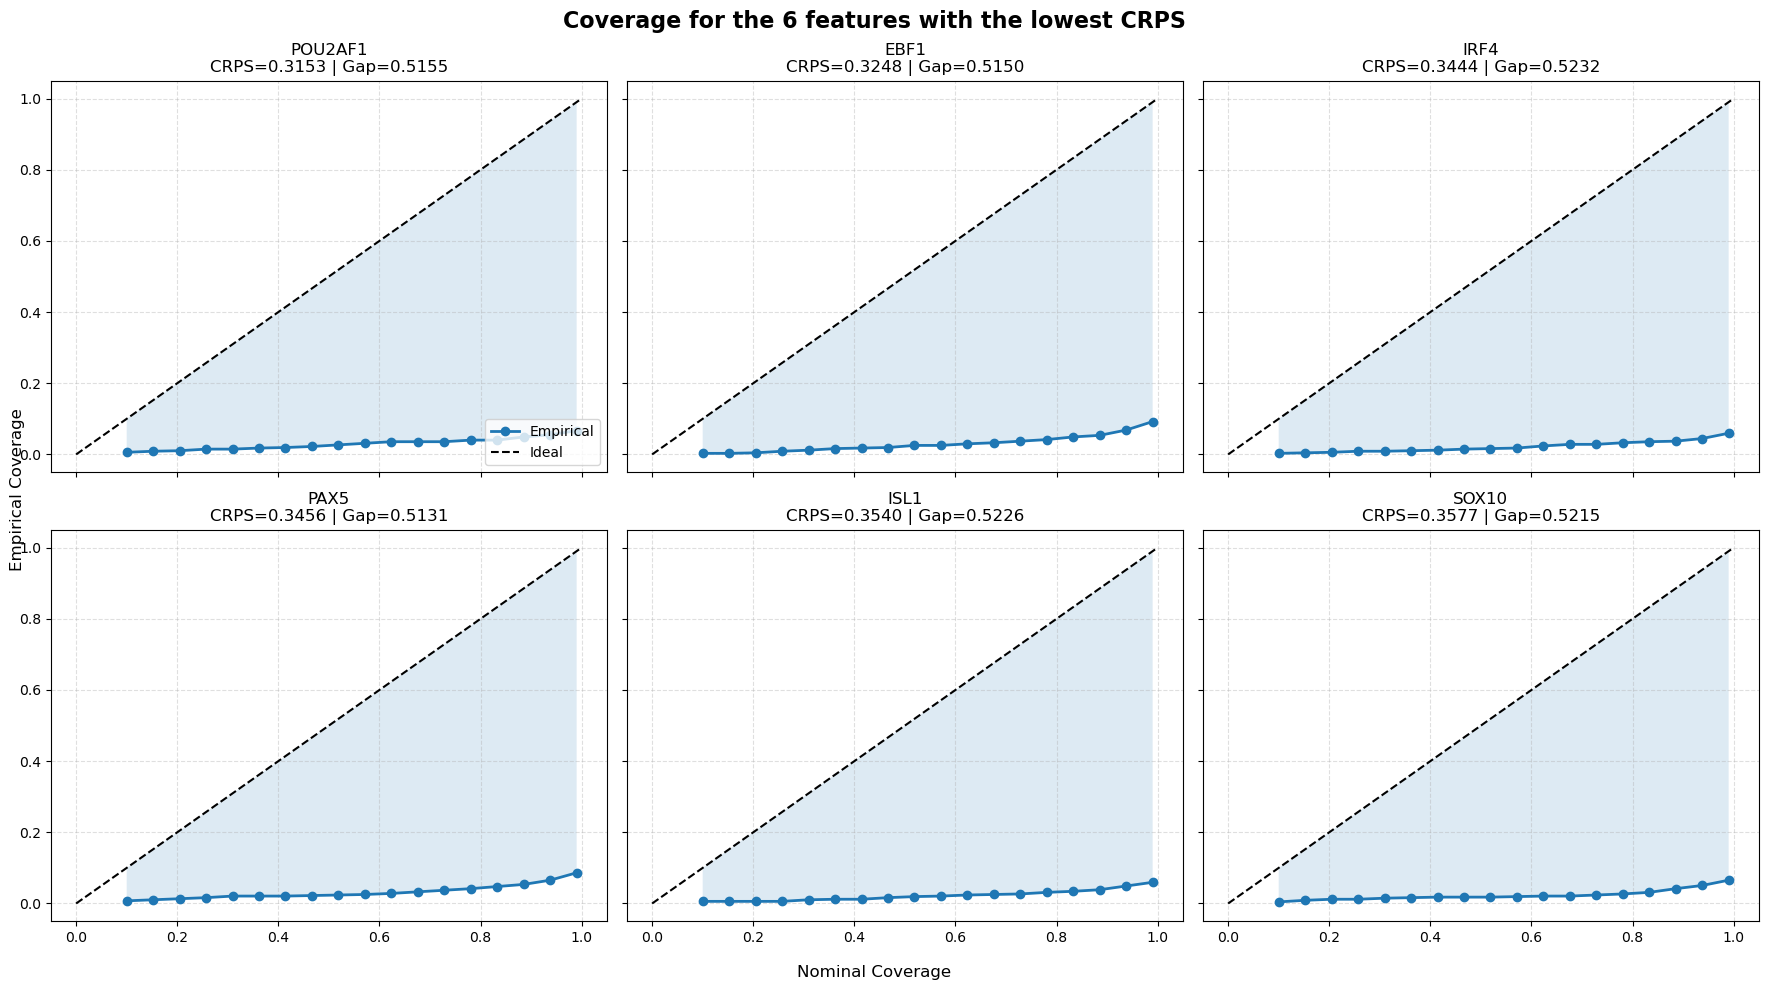

In [14]:
if RUN_DIAGRAMS:
    data, imputed, cube = om.load_prepared(OMIC, METHOD, PREPARED_SETTING)
    ence = m[OMIC][PREPARED_SETTING]["calibration"]
    crps = m[OMIC][PREPARED_SETTING]["scoring"]
    op.plot_ence_reliability(data, cube, ence.nlargest(6).index, ence, title="6 features with the highest ENCE")
    op.plot_ence_reliability(data, cube, ence.nsmallest(6).index, ence, title="6 features with the lowest ENCE")
    op.plot_ence_reliability(data, cube, ence.nsmallest(6).index, ence, style="line", title="6 features with the lowest ENCE")
    op.plot_coverage_calibration(data, cube, crps.nlargest(6).index, crps, title="Coverage for the 6 features with the highest CRPS")
    op.plot_coverage_calibration(data, cube, crps.nsmallest(6).index, crps, title="Coverage for the 6 features with the lowest CRPS")

## 8. One feature

Feature: GYPB


,IS
sharpness,0.030609
calibration,101.882146
scoring,0.608275
error,0.812181
pearson,0.601802


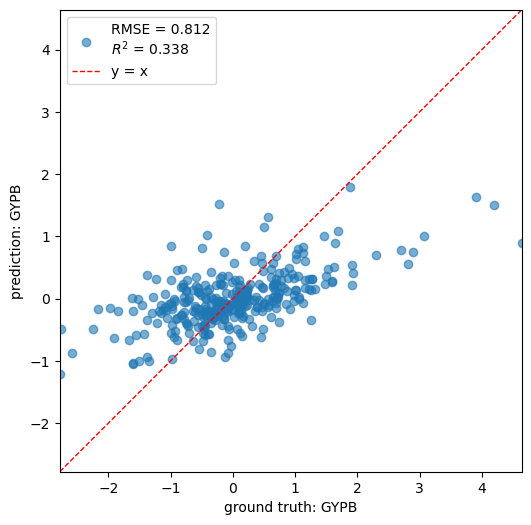

In [15]:
feature = FEATURE or is_["calibration"].idxmax()
print("Feature:", feature)
display(pd.DataFrame({s: {k: op.feature_metric(m, OMIC, s, k).get(feature, np.nan)
                          for k in ("sharpness", "calibration", "scoring", "error", "pearson")}
                      for s in m[OMIC]}))
if RUN_DIAGRAMS:
    op.plot_feature_truth_vs_prediction(data, imputed, feature)

## 9. CRISPR-Cas9 scaling check
Mean scaled ground truth per gene against the mean prediction (before z-scoring).

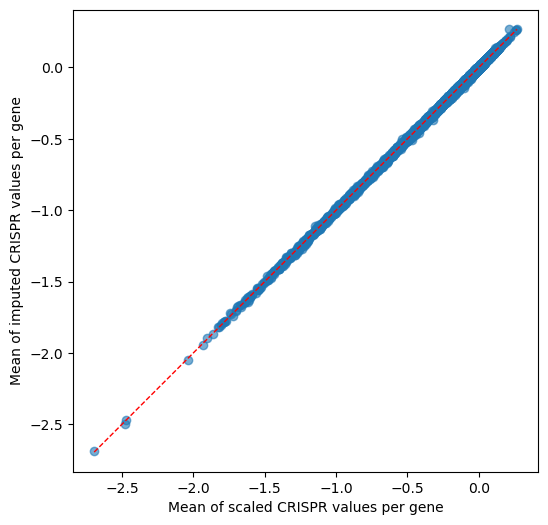

In [16]:
if OMIC == "crisprcas9" and RUN_DIAGRAMS:
    op.plot_truth_vs_prediction_means(om.load_ground_truth(OMIC), om.load_imputed(OMIC, "IS"),
                                      xlabel="Mean of scaled CRISPR values per gene",
                                      ylabel="Mean of imputed CRISPR values per gene")